# Fluid simulation using PhiFlow

In [1]:
from __future__ import annotations

import os
import time
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

import numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from phi.flow import (
    CenteredGrid, StaggeredGrid, Box, Sphere, Obstacle,
    extrapolation, fluid, advect, diffuse,
    spatial, batch,
)
import phi.math as math
import torch

from src.config import SimConfig, generate_random_config
from src.simulation import run_simulation
from src.visuals import plot_single_tensor_frame


## Main

In [2]:
# Setup delle simulazioni di prova

torch.manual_seed(42)

for i in range(1,5):
    # Genera config dinamica (nuovo seed per gli ostacoli, nuova velocità, ecc.)
    config = generate_random_config()
    
    # Sovrascriviamo eventuali setting grafici o di timestep se usavamo valori ad-hoc nel notebook:
    # config.dt = 0.05
    # config.colormap = "plasma"
    
    save_name = f"sim{i}.npy"
    print(f"\nSIMULATION: {i} <---")
    
    # Running simulation
    run_simulation(config, tensor_name=save_name, num_steps=50)



SIMULATION: 1 <---
  SIMULAZIONE FLUIDODINAMICA — PhiFlow
  Risoluzione : 224 × 224
  Steps       : 50  |  dt = 0.02 s
  Output dir  : sim_output
  Ostacolo 1 : Box (centro=1.19, 0.86 | 0.29×0.30 | rot=3.09)
  Ostacolo 2 : Box (centro=1.53, 0.71 | 0.23×0.26 | rot=2.22)


/opt/anaconda3/envs/fluid/lib/python3.10/site-packages/phiml/math/_optimize.py:640: UserWarning: Possible rank deficiency detected. Matrix might be singular which can lead to convergence problems. Please specify using Solve(rank_deficiency=...).
  warnings.warn("Possible rank deficiency detected. Matrix might be singular which can lead to convergence problems. Please specify using Solve(rank_deficiency=...).")


  step 0001/50  |  v_max=2.7551 m/s  |  smoke_avg=0.0021  |  dt_calc=559.0 ms
  step 0002/50  |  v_max=2.4033 m/s  |  smoke_avg=0.0036  |  dt_calc=517.7 ms
  step 0003/50  |  v_max=2.1039 m/s  |  smoke_avg=0.0054  |  dt_calc=456.3 ms
  step 0004/50  |  v_max=1.8649 m/s  |  smoke_avg=0.0072  |  dt_calc=452.0 ms
  step 0005/50  |  v_max=1.8198 m/s  |  smoke_avg=0.0092  |  dt_calc=471.5 ms
  step 0006/50  |  v_max=1.7881 m/s  |  smoke_avg=0.0113  |  dt_calc=452.6 ms
  step 0007/50  |  v_max=1.7596 m/s  |  smoke_avg=0.0135  |  dt_calc=452.0 ms
  step 0008/50  |  v_max=1.7330 m/s  |  smoke_avg=0.0159  |  dt_calc=457.6 ms
  step 0009/50  |  v_max=1.7074 m/s  |  smoke_avg=0.0184  |  dt_calc=455.3 ms
  step 0010/50  |  v_max=1.6819 m/s  |  smoke_avg=0.0210  |  dt_calc=448.9 ms
  step 0011/50  |  v_max=1.6653 m/s  |  smoke_avg=0.0237  |  dt_calc=448.8 ms
  step 0012/50  |  v_max=1.6513 m/s  |  smoke_avg=0.0266  |  dt_calc=448.2 ms
  step 0013/50  |  v_max=1.6379 m/s  |  smoke_avg=0.0296  |  dt_

Visualizzazione interattiva frame 50/50 (50, 3, 224, 224) (Chiudi la finestra per proseguire)


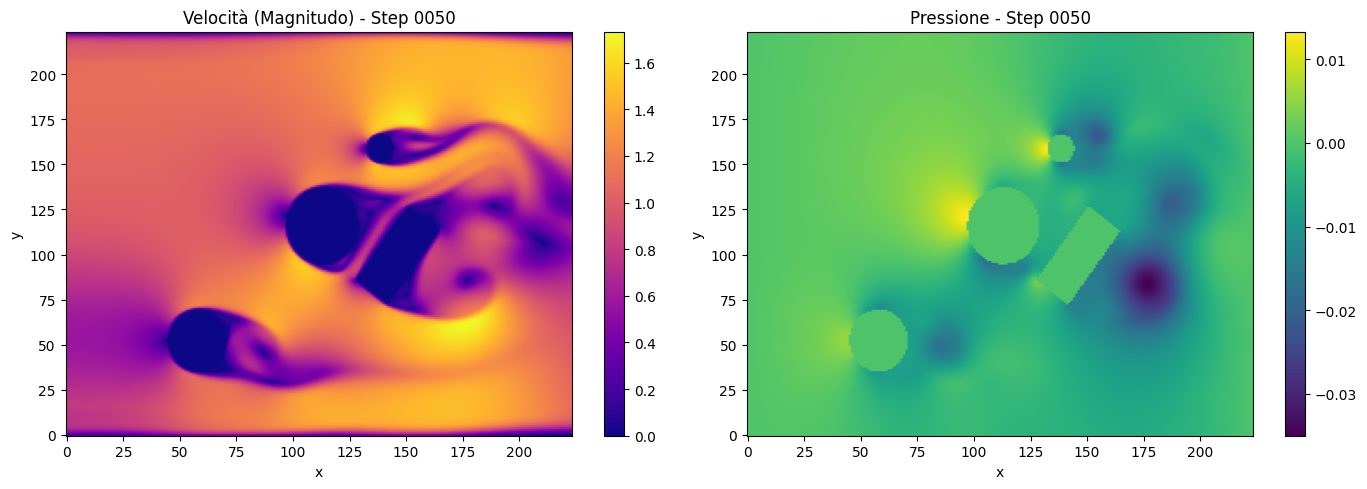

In [7]:
# Visualizza a schermo l'ultimo timeframe generato dal tensore (puoi cambiare index qui)
tensor_file = os.path.join(config.output_dir, "sim4.npy")
plot_single_tensor_frame(tensor_file, t_idx=50, colormap=config.colormap)